In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


data = pd.read_csv('Mall_Customers (1).csv')


data = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_data)

print(data.head())



   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   19                  15                      39        2
1   21                  15                      81        2
2   20                  16                       6        3
3   23                  16                      77        2
4   31                  17                      40        2


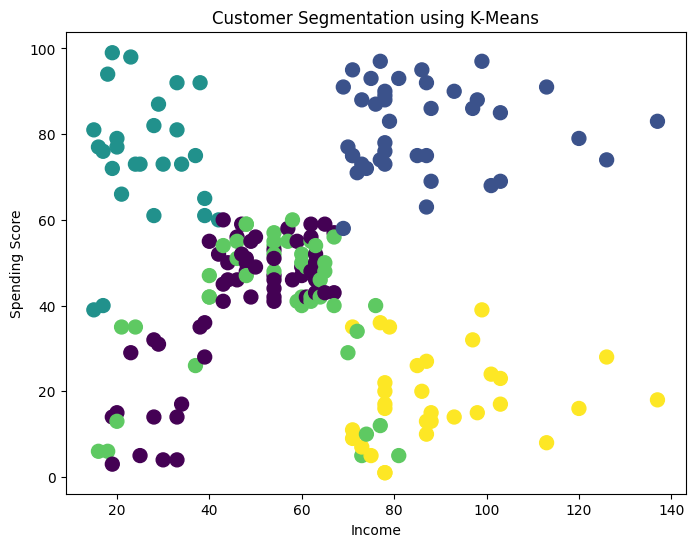

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=data['Cluster'], cmap='viridis', s=100)

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')

plt.show()

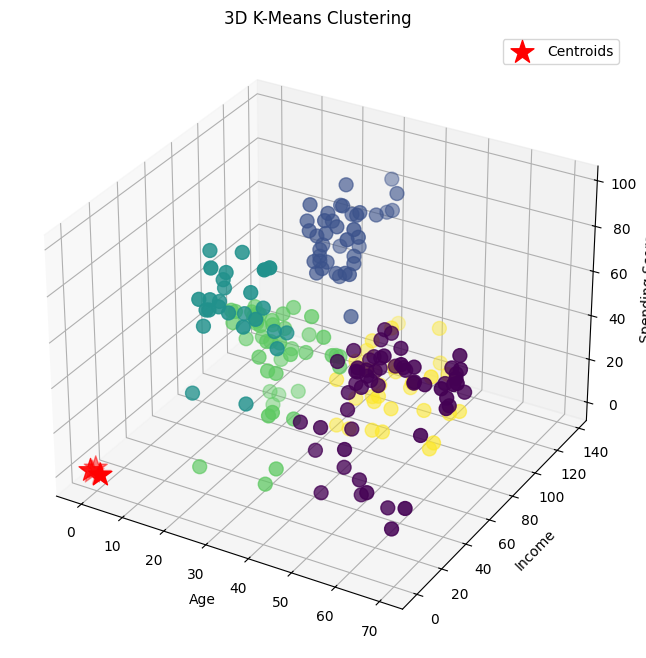

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data['Age'],
           data['Annual Income (k$)'],
           data['Spending Score (1-100)'],
           c=data['Cluster'], cmap='viridis', s=100)

centers = kmeans.cluster_centers_
ax.scatter(centers[:,0], centers[:,1], centers[:,2],
           c='red', s=300, marker='*', label='Centroids')

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')
ax.set_title('3D K-Means Clustering')

plt.legend()
plt.show()

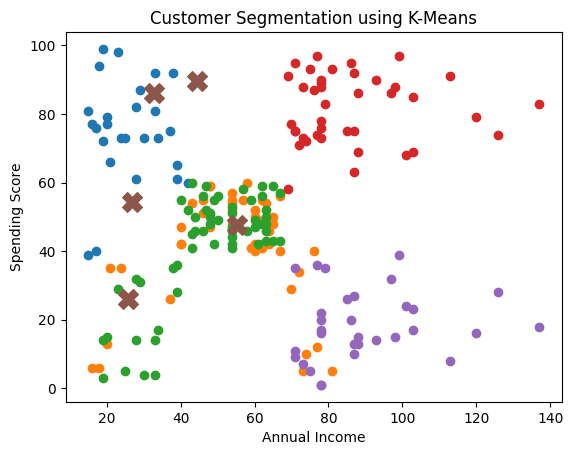

In [10]:
import matplotlib.pyplot as plt


plt.figure()

for cluster in data['Cluster'].unique():
    cluster_data = data[data['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'])


centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='X', s=200)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()